In [1]:
# ============================================================
# Cell 1: Install required libraries
# ============================================================
!pip install fairlearn shap lime -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 40.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# Cell 2: Import libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    true_positive_rate
)

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [4]:
# ============================================================
# Cell 3: Load and inspect dataset (Adult Census Income)
# ============================================================
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)
df.dropna(inplace=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# ============================================================
# Cell 4: Dataset preparation
# ============================================================

# Target variable (binary)
df["income"] = df["income"].apply(lambda x: 1 if x.strip() == ">50K" else 0)

# Sensitive attribute (Gender)
df["sex_binary"] = df["sex"].apply(lambda x: 1 if x == "Male" else 0)

# Feature selection
feature_columns = [
    "age", "education-num", "capital-gain", "capital-loss",
    "hours-per-week", "workclass", "marital-status",
    "occupation", "relationship", "race", "native-country"
]

X = df[feature_columns]
y = df["income"]
sensitive = df["sex_binary"]

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

print("\nSensitive attribute distribution:")
print(sensitive.value_counts(normalize=True))


Target distribution:
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64

Sensitive attribute distribution:
sex_binary
1    0.669205
0    0.330795
Name: proportion, dtype: float64


In [7]:
# ============================================================
# Cell 5: Train-test split
# ============================================================
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sensitive,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:
# ============================================================
# Cell 6: Preprocessing & Model Pipeline
# ============================================================
numeric_features = [
    "age", "education-num", "capital-gain",
    "capital-loss", "hours-per-week"
]

categorical_features = [
    "workclass", "marital-status", "occupation",
    "relationship", "race", "native-country"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

In [12]:
# ============================================================
# Cell 7: Model training
# ============================================================
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MODEL PERFORMANCE
Accuracy: 0.8554 (85.54%)

Confusion Matrix:
[[4603  342]
 [ 600  968]]

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.86      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513



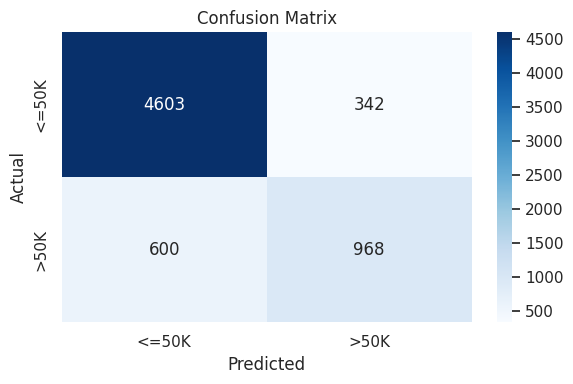

In [13]:
# ============================================================
# Cell 8: Model evaluation
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(
    y_test, y_pred,
    target_names=["<=50K", ">50K"]
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(class_report)

# Confusion Matrix plot
plt.figure(figsize=(6,4))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Cell 9: Fairness Analysis (Fairlearn)
# ============================================================
metrics = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate
}

metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=s_test
)

print("=" * 50)
print("FAIRNESS METRICS BY GENDER")
print("=" * 50)
print(metric_frame.by_group)


FAIRNESS METRICS BY GENDER
            selection_rate  false_positive_rate  true_positive_rate
sex_binary                                                         
0                 0.089435             0.025091            0.591837
1                 0.256487             0.096966            0.622071


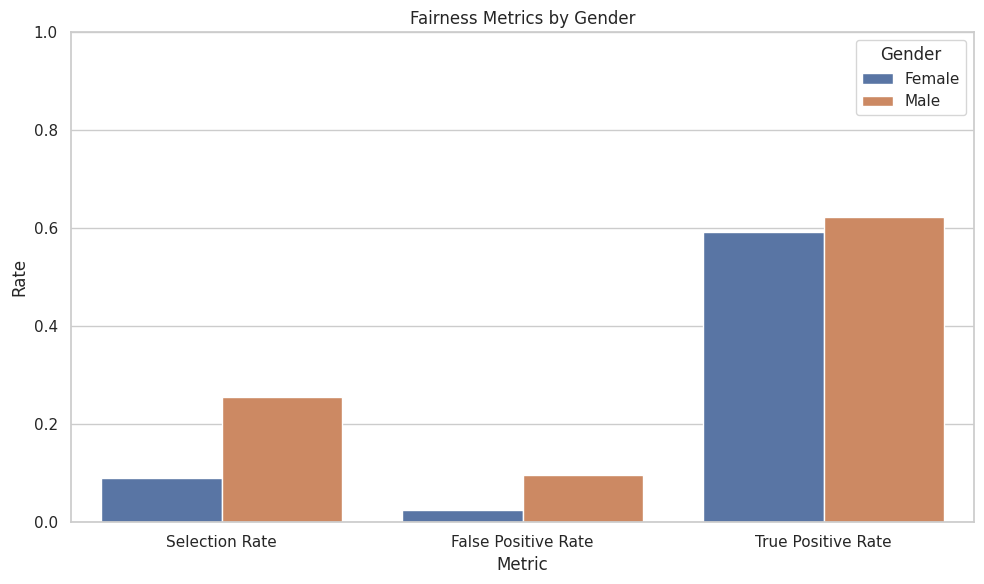

In [16]:
# ============================================================
# Cell 10: Fairness metrics visualization
# ============================================================
metrics_df = pd.DataFrame({
    "Metric": ["Selection Rate", "False Positive Rate", "True Positive Rate"],
    "Female": [
        metric_frame.by_group.loc[0, "selection_rate"],
        metric_frame.by_group.loc[0, "false_positive_rate"],
        metric_frame.by_group.loc[0, "true_positive_rate"]
    ],
    "Male": [
        metric_frame.by_group.loc[1, "selection_rate"],
        metric_frame.by_group.loc[1, "false_positive_rate"],
        metric_frame.by_group.loc[1, "true_positive_rate"]
    ]
})

metrics_melted = metrics_df.melt(
    id_vars="Metric",
    var_name="Gender",
    value_name="Rate"
)

plt.figure(figsize=(10,6))
sns.barplot(data=metrics_melted, x="Metric", y="Rate", hue="Gender")
plt.title("Fairness Metrics by Gender")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

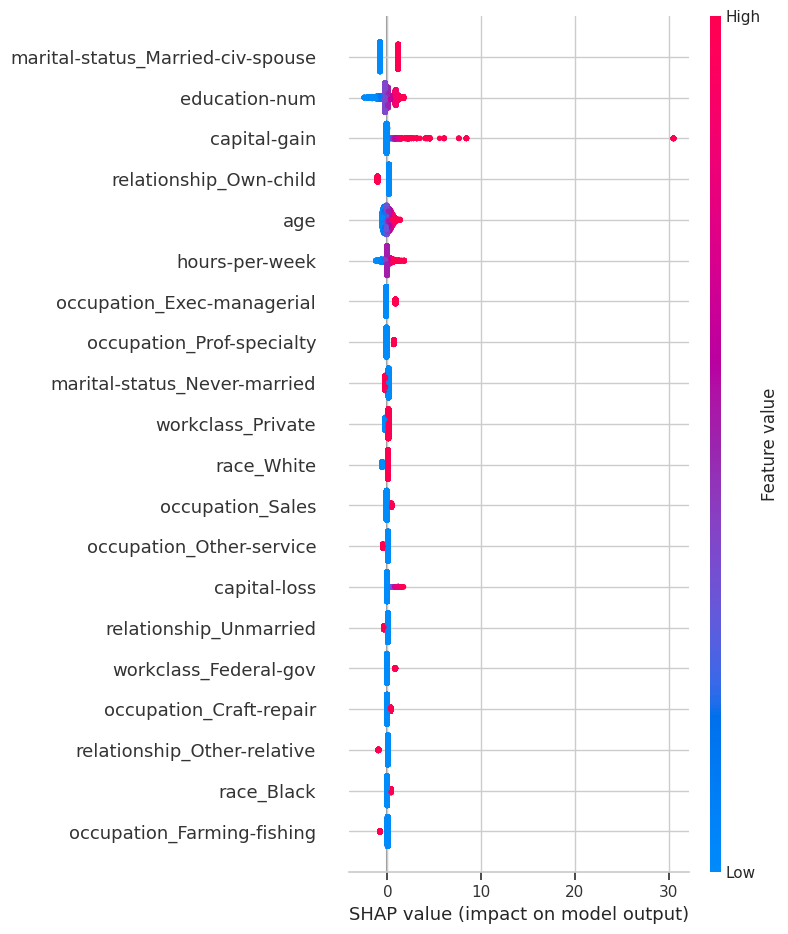

In [17]:
# ============================================================
# Cell 12: SHAP Explainability (FAST & STABLE)
# ============================================================
X_train_prep = model.named_steps["preprocessor"].transform(X_train)
X_test_prep = model.named_steps["preprocessor"].transform(X_test)

feature_names = (
    numeric_features +
    list(
        model.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
)

X_train_df = pd.DataFrame(X_train_prep, columns=feature_names)
X_test_df = pd.DataFrame(X_test_prep, columns=feature_names)

explainer = shap.LinearExplainer(
    model.named_steps["classifier"],
    X_train_df
)

shap_values = explainer(X_test_df)

# Global SHAP
shap.summary_plot(shap_values, X_test_df, show=True)

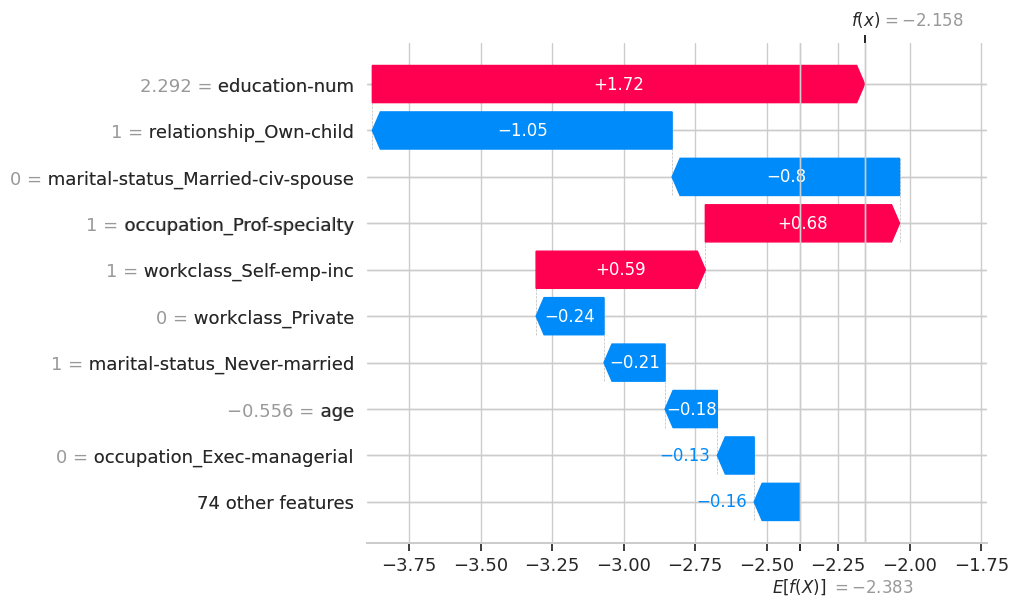

In [18]:
# ============================================================
# Cell 13: SHAP Local Explanation
# ============================================================
instance = 0
shap.plots.waterfall(shap_values[instance])

In [20]:
# ============================================================
# Cell 15: Final Summary
# ============================================================
print("=" * 60)
print(" ANALYSIS COMPLETE")
print("=" * 60)
print(f"Final Accuracy: {accuracy*100:.2f}%")
print("Fairness and explainability successfully evaluated.")

 ANALYSIS COMPLETE
Final Accuracy: 85.54%
Fairness and explainability successfully evaluated.
